In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
df.columns

Index(['Unnamed: 0', 'TV Ad Budget ($)', 'Radio Ad Budget ($)',
       'Newspaper Ad Budget ($)', 'Sales ($)'],
      dtype='object')

In [2]:
df = pd.read_csv(r"C:\Users\Ahmet\Downloads\Advertising Budget and Sales.csv")
df.head()

,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [6]:
df = df.drop(columns=["Unnamed: 0"])

df.columns = [
    "TV_Spend",
    "Radio_Spend",
    "News_Spend",
    "Sales"
]

## Feature Engineering

In [11]:
# Toplam reklam harcamasını hesaplıyoruz
# Bu metrik toplam bütçeyi temsil eder
df["Total_Spend"] = df["TV_Spend"] + df["Radio_Spend"] + df["News_Spend"]

# ROI (Return on Investment)
# Amaç: yapılan harcamanın satışa ne kadar katkı sağladığını ölçmek
df["ROI"] = (df["Sales"] - df["Total_Spend"]) / df["Total_Spend"]

# kanal bazlı bütçe oranı
# Bu sayede hangi kanala ne kadar yatırım yapıldığını analiz edebiliriz
df["TV_pct"] = df["TV_Spend"] / df["Total_Spend"]
df["Radio_pct"] = df["Radio_Spend"] / df["Total_Spend"]
df["News_pct"] = df["News_Spend"] / df["Total_Spend"]

df.head()

,TV_Spend,Radio_Spend,News_Spend,Sales,Total_Spend,ROI,TV_pct,Radio_pct,News_pct
0,230.1,37.8,69.2,22.1,337.1,-0.934441,0.682587,0.112133,0.205280
1,44.5,39.3,45.1,10.4,128.9,-0.919317,0.345229,0.304888,0.349884
2,17.2,45.9,69.3,9.3,132.4,-0.929758,0.129909,0.346677,0.523414
3,151.5,41.3,58.5,18.5,251.3,-0.926383,0.602865,0.164345,0.232789
4,180.8,10.8,58.4,12.9,250.0,-0.948400,0.723200,0.043200,0.233600


             TV_Spend  Radio_Spend  News_Spend     Sales
TV_Spend     1.000000     0.054809    0.056648  0.782224
Radio_Spend  0.054809     1.000000    0.354104  0.576223
News_Spend   0.056648     0.354104    1.000000  0.228299
Sales        0.782224     0.576223    0.228299  1.000000


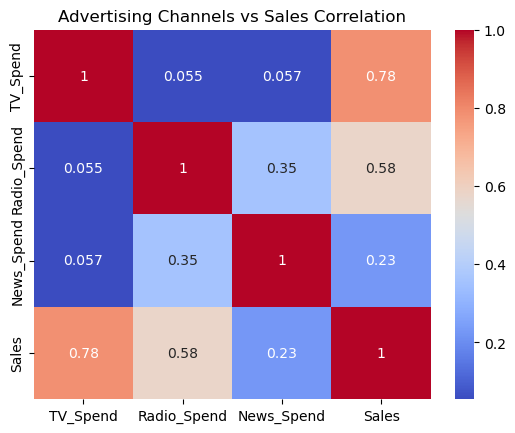

In [12]:
# Reklam kanalları ile satış arasındaki ilişkiyi ölçüyoruz
# Correlation değeri 1'e ne kadar yakınsa ilişki o kadar güçlüdür
corr = df[["TV_Spend", "Radio_Spend", "News_Spend", "Sales"]].corr()

print(corr)

# Korelasyonları görselleştiriyoruz
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Advertising Channels vs Sales Correlation")
plt.show()

### Satışlar ile Tv harcaması arasında yüksek korelasyon var, yani en çok tv reklamları ile satış artıyor

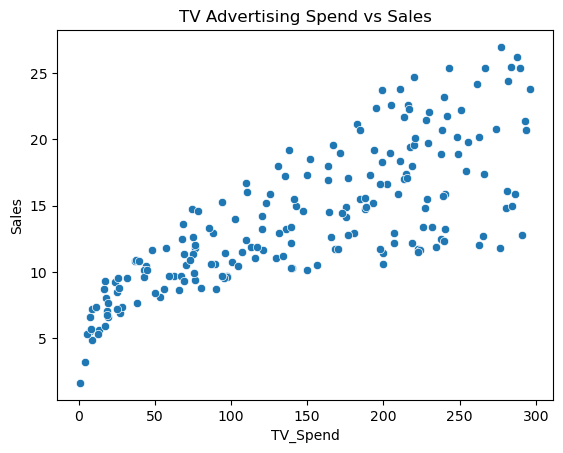

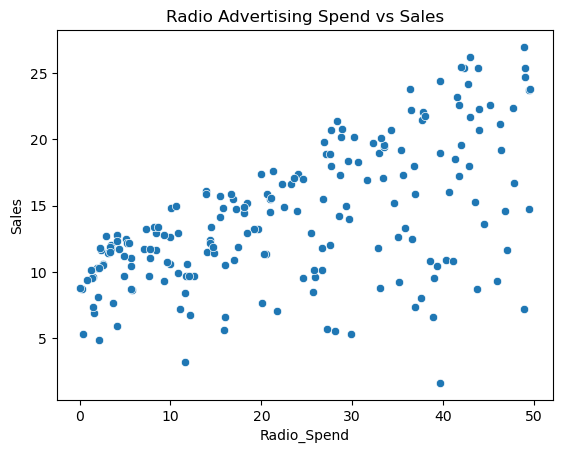

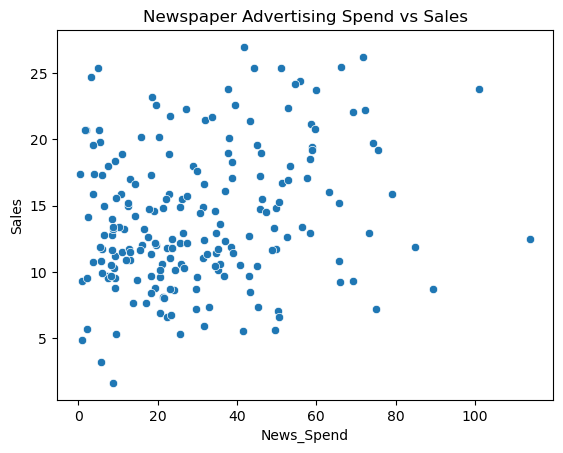

In [14]:
# TV reklam harcaması ile satış arasındaki ilişki
sns.scatterplot(x="TV_Spend", y="Sales", data=df)
plt.title("TV Advertising Spend vs Sales")
plt.show()

# Radio reklam harcaması ile satış arasındaki ilişki
sns.scatterplot(x="Radio_Spend", y="Sales", data=df)
plt.title("Radio Advertising Spend vs Sales")
plt.show()

# Newspaper reklam harcaması ile satış arasındaki ilişki
sns.scatterplot(x="News_Spend", y="Sales", data=df)
plt.title("Newspaper Advertising Spend vs Sales")
plt.show()

### Burda da grafikte görüldüğü üzere en çok TV reklamları ile en az Gazete reklamları ile satışlar artmış

In [15]:
# Her reklam kanalının ortalama harcamasını ve satışla olan ilişkisini ölçüyoruz
efficiency = pd.DataFrame({
    "Channel": ["TV", "Radio", "Newspaper"],
    
    # Ortalama harcama (budget allocation)
    "Avg_Spend": [
        df["TV_Spend"].mean(),
        df["Radio_Spend"].mean(),
        df["News_Spend"].mean()
    ],
    
    # Kanalın satış üzerindeki etkisi (correlation)
    "Correlation_with_Sales": [
        df["TV_Spend"].corr(df["Sales"]),
        df["Radio_Spend"].corr(df["Sales"]),
        df["News_Spend"].corr(df["Sales"])
    ]
})

print(efficiency)

     Channel  Avg_Spend  Correlation_with_Sales
0         TV   147.0425                0.782224
1      Radio    23.2640                0.576223
2  Newspaper    30.5540                0.228299


In [16]:
# ROI dağılımını inceliyoruz
# Bu bize genel olarak reklam yatırımlarının ne kadar verimli olduğunu gösterir
roi_summary = df["ROI"].describe()

print(roi_summary)

count    200.000000
mean      -0.921269
std        0.032841
min       -0.967347
25%       -0.936807
50%       -0.926467
75%       -0.911651
max       -0.589744
Name: ROI, dtype: float64


### “ROI, parasal olmayan satış değerleri nedeniyle doğrudan yorumlanamaz”

In [18]:
# Her kanalın satış ile korelasyonunu hesaplıyoruz
tv_corr = df["TV_Spend"].corr(df["Sales"])
radio_corr = df["Radio_Spend"].corr(df["Sales"])
news_corr = df["News_Spend"].corr(df["Sales"])

print("İÇ GÖRÜLER VE ÖNERİLER:")

# Daha verimli kanal tespiti
if radio_corr > tv_corr:
    print("→ Radyo reklamları televizyondan daha etkilidir. Bütçe payını artırmayı düşünün.")

# Düşük performanslı kanal
if news_corr < 0.1:
    print("→ Gazete ilanlarının etkisi çok azdır. Bütçe azaltılabilir.")

# Güçlü ama optimize edilmesi gereken kanal
if tv_corr > radio_corr:
    print("→ Televizyon reklamları satışları artırır, ancak maliyet verimliliği açısından optimize edilmelidir.")

İÇ GÖRÜLER VE ÖNERİLER:
→ Televizyon reklamları satışları artırır, ancak maliyet verimliliği açısından optimize edilmelidir.


In [19]:
# Analiz sonuçlarını Excel'e aktarıyoruz
# Bu dosya dashboard oluşturmak için kullanılabilir
df.to_excel("advertising_analysis.xlsx", index=False)

# Kanal bazlı özet tablo
efficiency.to_excel("channel_summary.xlsx", index=False)